In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from tqdm import tqdm
from paretoset import paretoset

import model_functions as fmodel

# Matrix ISA Model Example Usage

### Number of Registers to Hide Memory Latency

using larger memories with higher latency requires more matrix registers to acheive high utilization. below is a plot showing how utilization is affected by memory latency for different matrix register counts.

100%|██████████| 7/7 [00:00<00:00, 1017.72it/s]


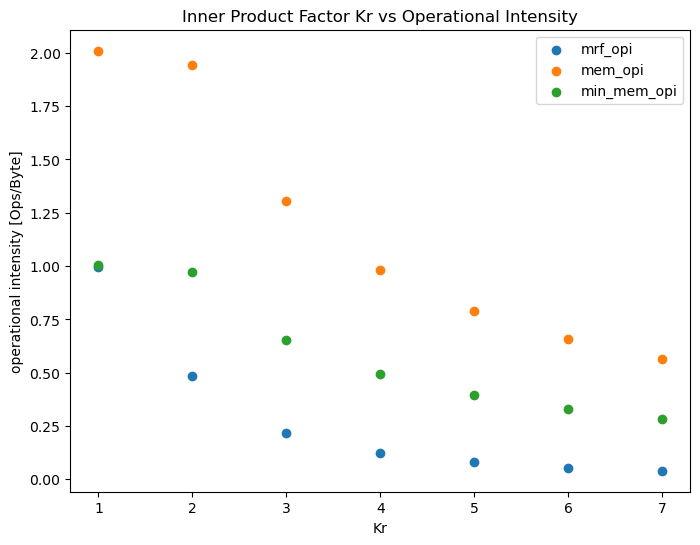

In [2]:
fig, axs = plt.subplots(figsize=(8,6))
axs.set_title('Inner Product Factor Kr vs Operational Intensity')
axs.set_xlabel('Kr')
axs.set_ylabel('operational intensity [Ops/Byte]')

kls = np.array(range(1,8))
perf_model = fmodel.init_pm(K=np.array([100*8]), kl=kls)

# x = perf_model.index.levels[level]
max_mem_bw = perf_model['max_mem_bw']
mem_bw = perf_model['mem_bw']
mrf_bw = perf_model['mrf_bw']
opc = perf_model['ops_cycle']
mem_opi = opc/mem_bw
min_mem_opi = opc/max_mem_bw
mrf_opi = opc/mrf_bw

scatter = axs.scatter(kls, mrf_opi)
scatter = axs.scatter(kls, mem_opi)
scatter = axs.scatter(kls, min_mem_opi)
axs.legend(['mrf_opi', 'mem_opi', 'min_mem_opi'])


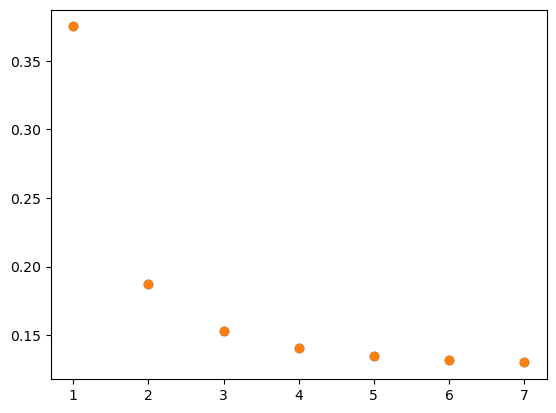

In [3]:
mrf_capacity = perf_model['mrf_capacity']
max_mrf_capacity = perf_model['max_mrf_capacity']
plt.scatter(kls, mrf_capacity)
plt.scatter(kls, max_mrf_capacity)


### Exploring Design Space

The model can be used to sweep ranges of the input parameters, and the output performance specs can be visualized using pareto-optimal curves.

With these plots we can visualize the tradeoffs between ngates capacity, memory bandwidth, and performance (operations per cycle).

In [ ]:
perf_model = fmodel.init_pm(
    mlB = np.array(range(128,513, 32))/8,
    vlB = np.array([128, 256, 512])/8,
    kl = np.array([1,2,4,8]),
    N = np.array(range(4,64, 8)),
    M = np.array(range(4,64, 8)),
    K = np.array(range(4,64, 8)),
    num_mregs = np.array(range(2,6,2)),
    t_op = np.array([2]),
    widen = np.array([1,2,4]),
    width_mmu = np.array([1])
)


  0%|          | 1296/479232 [00:01<05:44, 1387.29it/s]

In [ ]:
fperf_model = perf_model.copy()
fperf_model = fperf_model[fperf_model['max_mem_bw'] <= 64]
fperf_model = fperf_model[fperf_model['mrf_capacity'] <= 128]
# perf_model = perf_model[perf_model['ops_cycle'] >= 1/4e-2]

pm_pareto = perf_model[['ops_cycle','opu_gates', 'max_mem_bw']]
mask = paretoset(pm_pareto, sense=['max', 'min', 'min'])

bw = perf_model.loc[mask,'max_mem_bw']
ngates = perf_model.loc[mask,'opu_gates']
opc = perf_model.loc[mask,'ops_cycle']

fig, axs = plt.subplots(1,figsize=(6,6))
axs.set_title('Pareto Optimal Front')
axs.set_xlabel('Cycles per Operation')
axs.set_ylabel('Estimated Area [cmos gates]')

axs.scatter(1/opc, ngates, c=bw, cmap='viridis', s=100)
axs.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
fig.colorbar(scatter, ax=axs, label='Memory Bandwidth [Bytes/cycle]')

In [ ]:
mrf = perf_model.loc[mask,'mrf_capacity']
plt.scatter(mrf, ngates)
plt.xlabel('MRF Capacity [KB]')
plt.ylabel('Estimated Area [cmos gates]')

In [ ]:
perf_model = fmodel.init_pm(
    mlB = np.array(range(128,513, 32))/8,
    vlB = np.array([128, 256, 512])/8,
    N = np.array(range(4,64, 8)),
    M = np.array(range(4,64, 8)),
    K = np.array(range(4,64, 8)),
    num_mregs = np.array(range(2,6,2))
)
perf_model = perf_model[perf_model['max_mem_bw'] <= 64]
perf_model = perf_model[perf_model['ops_cycle'] >= 1/4e-2]

max_mem_bw = perf_model.loc[mask,'max_mem_bw']
mem_bw = perf_model.loc[mask,'mem_bw']
mrf_bw = perf_model.loc[mask,'mrf_bw']
max_mrf_bw = perf_model.loc[mask,'max_mrf_bw']
ngates = perf_model.loc[mask,'opu_gates']
opc = perf_model.loc[mask,'ops_cycle']
mem_opi = opc/mem_bw
min_mem_opi = opc/max_mem_bw
mrf_opi = opc/mrf_bw
min_mrf_opi = opc/max_mrf_bw

fig, axs = plt.subplots(1,figsize=(6,6))
axs.set_title('Pareto Optimal Front')
axs.set_xlabel('Cycles per Operation')
axs.set_ylabel('Estimated Area [cmos gates]')

axs.scatter(1/opc, ngates, c=bw, cmap='viridis', s=100)
axs.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
fig.colorbar(scatter, ax=axs, label='Memory Bandwidth [Bytes/cycle]')
perf_model[mask]

In [ ]:
# mlB = np.array(range(128,513, 64))/8
mlB = np.array([128, 256, 512])/8
vlB = np.array([128, 256, 512])/8
num_mregs = np.array(range(2,6,2))
t_op = np.array([0, 1, 2])
width_mmu = np.array([0.5, 1])

fig, axs = plt.subplots(len(mlB),len(vlB), figsize=(8*len(mlB), 6*len(vlB)))
for n in range(len(vlB)):
    for m in range(len(mlB)):
        if mlB[m] <= vlB[n]:
            perf_model = fmodel.init_pm(mlB=np.array([mlB[m]]), vlB=np.array([vlB[n]]),                   
                                        N = np.array(range(4,64, 8)),
                                        M = np.array(range(4,64, 8)),
                                        K = np.array(range(4,64, 8)))

            # Create a 3x3 subplot
            ax = axs[m,n]
            ax.set_title(f'Speedup vs Utilization for MLEN={int(mlB[m]*8)} and VLEN={int(8*vlB[n])}')
            ax.set_xlabel('Speedup over Vector Unit')
            ax.set_ylabel('Utilization')
            perf_model['tile_size'] = perf_model.index.get_level_values('N') * perf_model.index.get_level_values('M') + perf_model.index.get_level_values('M') * perf_model.index.get_level_values('K') + perf_model.index.get_level_values('N') * perf_model.index.get_level_values('K')
            ax.scatter(perf_model['speedup_vec'], perf_model['util'],  
                                    c=perf_model['tile_size'], cmap='viridis')
            cbar = plt.colorbar(scatter, ax=ax)
plt.show()

In [ ]:

# mlB = np.array(range(128,513, 32))/8
mlB = np.array([128, 256, 512])/8
vlB = np.array([128, 256, 512])/8
num_mregs = np.array(range(2,6,2))
t_op = np.array([0, 1, 2])
width_mmu = np.array([0.5, 1])

fig, axs = plt.subplots(len(t_op), len(width_mmu), figsize=(18, 18))
for m in range(len(t_op)):
    for n in range(len(width_mmu)):
        perf_model = fmodel.init_pm(t_op=np.array([t_op[m]]), width_mmu=np.array([width_mmu[n]]),                   
                                    N = np.array(range(4,64, 8)),
                                    M = np.array(range(4,64, 8)),
                                    K = np.array(range(4,64, 8)))

        # Create a 3x3 subplot
        ax = axs[m,n]
        ax.set_title(f't_op: {t_op[m]} and width={width_mmu[n]}')
        ax.set_xlabel('Speedup over Vector Unit')
        ax.set_ylabel('Utilization')
        perf_model['tile_size'] = perf_model.index.get_level_values('N') * perf_model.index.get_level_values('M')
        scatter = ax.scatter(perf_model['speedup_vec'], perf_model['util'],  
                                c=perf_model['tile_size'], cmap='viridis')
        cbar = plt.colorbar(scatter, ax=ax)
plt.show()

In [ ]:

# mlB = np.array(range(128,513, 32))/8
mlB = np.array([128, 256, 512])/8
vlB = np.array([128, 256, 512])/8
num_mregs = np.array(range(2,6,2))
t_op = np.array([0, 1, 2])
width_mmu = np.array([0.5, 1])

def plot_nmk_scatter(x, y):
    fig, axs = plt.subplots(len(t_op), len(width_mmu), figsize=(18, 18))
    for m in range(len(t_op)):
        for n in range(len(width_mmu)):
                perf_model = fmodel.init_pm(t_op=np.array([t_op[m]]), width_mmu=np.array([width_mmu[n]]),                   
                                            N = np.array(range(4,64, 8)),
                                            M = np.array(range(4,64, 8)),
                                            K = np.array(range(4,64, 8)))

                # Create a 3x3 subplot
                ax = axs[m,n]
                ax.set_title(f'Speedup vs Utilization for MLEN={int(mlB[m]*8)} and VLEN={int(8*vlB[n])}')
                ax.set_xlabel('Speedup over Vector Unit')
                ax.set_ylabel('Utilization')
                perf_model['tile_size'] = perf_model.index.get_level_values('N') * perf_model.index.get_level_values('M')
                scatter = ax.scatter(perf_model['speedup_vec'], perf_model['util'],  
                                        c=perf_model['tile_size'], cmap='viridis')
                cbar = plt.colorbar(scatter, ax=ax)
    plt.show()

In [ ]:
# Group by M, N, K and find the maximum speedup_vec for each group
avg_nmk = perf_model.groupby(['vlB', 'mlB', 'num_mregs', 't_op', 'width_mmu'])['util'].mean().reset_index()
avg_speedup = perf_model.groupby(['vlB', 'mlB', 'num_mregs', 't_op', 'width_mmu'])['speedup_vec'].mean().reset_index()
avg_nmk['speedup_vec'] = avg_speedup['speedup_vec']

pm_pareto = avg_nmk[['speedup_vec','util']]
mask = paretoset(pm_pareto, sense=['max', 'max'])

# Plot speedup vs (N*M + N*K + M*K)
fig, axs = plt.subplots(figsize=(8, 6))
axs.set_title('Speedup vs Utilization')
axs.set_xlabel('Speedup over Vector Unit')
axs.set_ylabel('Utilization')

scatter = axs.scatter(avg_nmk['speedup_vec'], avg_nmk['util'])
plt.show()
# Write the output to a file
with open('avg_nmk.txt', 'w') as f:
    sorted = avg_nmk.sort_values(by='speedup_vec', ascending=False)
    f.write(sorted.to_string())
avg_nmk

In [ ]:
# Group by M, N, K and find the maximum speedup_vec for each group
max_speedup = perf_model.groupby(['M', 'N', 'K'])['util'].max().reset_index()
max_speedup = max_speedup[max_speedup['util'] <= 0.7]

max_speedup['NM_NK_MK'] = max_speedup['N'] * max_speedup['M'] + max_speedup['N'] * max_speedup['K'] + max_speedup['M'] * max_speedup['K']

# Plot speedup vs (N*M + N*K + M*K)
fig, axs = plt.subplots(figsize=(8, 6))
axs.set_title('Speedup vs (N*M + N*K + M*K)')
axs.set_xlabel('N*M + N*K + M*K')
axs.set_ylabel('Utilization')

scatter = axs.scatter(max_speedup['NM_NK_MK'], max_speedup['util'])
plt.show()
# Write the output to a file
with open('util.txt', 'w') as f:
    sorted_speedup = max_speedup
    f.write(sorted_speedup.to_string())
max_speedup

In [ ]:
# Group by M, N, K and find the maximum speedup_vec for each group
max_speedup = perf_model.groupby(['M', 'N', 'K'])['speedup_vec'].min().reset_index()
# max_speedup = max_speedup[max_speedup['speedup_vec'] <= 20]

# Write the output to a file
with open('speedup_vec.txt', 'w') as f:
    sorted_speedup = max_speedup
    f.write(sorted_speedup.to_string())
max_speedup['NM_NK_MK'] = max_speedup['N'] * max_speedup['M'] + max_speedup['N'] * max_speedup['K'] + max_speedup['M'] * max_speedup['K']

# Plot speedup vs (N*M + N*K + M*K)
fig, axs = plt.subplots(figsize=(8, 6))
axs.set_title('Speedup vs (N*M + N*K + M*K)')
axs.set_xlabel('N*M + N*K + M*K')
axs.set_ylabel('Speedup')

scatter = axs.scatter(max_speedup['NM_NK_MK'], max_speedup['speedup_vec'])
plt.show()

# Scatter plot M vs N with color=speedup
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(max_speedup['M'], max_speedup['N'], c=max_speedup['speedup_vec'], cmap='viridis')
ax.set_title('M vs N with Speedup as Color')
ax.set_xlabel('M')
ax.set_ylabel('N')
fig.colorbar(scatter, ax=ax, label='Speedup')
plt.show()

max_speedup['speedup_vec']

In [ ]:
# Calculate the new variable (N*M + N*K + M*K)
perf_model['NM_NK_MK'] = perf_model.index.get_level_values('N') * perf_model.index.get_level_values('M') + \
                         perf_model.index.get_level_values('N') * perf_model.index.get_level_values('K') + \
                         perf_model.index.get_level_values('M') * perf_model.index.get_level_values('K')

pm_pareto = perf_model[['NM_NK_MK', 'speedup_vec']]
mask = paretoset(pm_pareto, sense=['min', 'max'])

# Plot speedup vs (N*M + N*K + M*K)
fig, axs = plt.subplots(figsize=(8, 6))
axs.set_title('Worst Case Speedup for [N, M, K]')
axs.set_xlabel('N*M + N*K + M*K')
axs.set_ylabel('Speedup')

# Create a bar plot with x-axis as the combination of N, M, and K
x_labels = [f'{n},{m},{k}' for n, m, k in zip(perf_model.loc[mask].index.get_level_values('N'), 
                                              perf_model.loc[mask].index.get_level_values('M'), 
                                              perf_model.loc[mask].index.get_level_values('K'))]

speedup = perf_model.loc[mask, 'speedup_vec']
utilization = perf_model.loc[mask, 'util']
scatter = axs.bar(x_labels, speedup, color=plt.cm.viridis(utilization))
axs.set_xticklabels(x_labels, rotation=90)

sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=utilization.min(), vmax=utilization.max()))
sm.set_array([])
cbar = plt.colorbar(sm, ax=axs)
cbar.set_label('Utilization')
plt.show()
perf_model.loc[mask].reset_index(level=['databits', 't_mem', 'l2_cache', 'kl', 'num_mregs', 't_op', 'width_mmu'], drop=True)

In [ ]:
# Calculate the new variable (N*M + N*K + M*K)
perf_model['NM_NK_MK'] = perf_model.index.get_level_values('N') * perf_model.index.get_level_values('M') + \
                         perf_model.index.get_level_values('N') * perf_model.index.get_level_values('K') + \
                         perf_model.index.get_level_values('M') * perf_model.index.get_level_values('K')

pm_pareto = perf_model[['NM_NK_MK', 'speedup_vec']]
mask = paretoset(pm_pareto, sense=['max', 'min'])

# Plot speedup vs (N*M + N*K + M*K)
fig, axs = plt.subplots(figsize=(8, 6))
axs.set_title('Best Case Speedup for [N, M, K]')
axs.set_xlabel('N*M + N*K + M*K')
axs.set_ylabel('Speedup')

# Create a bar plot with x-axis as the combination of N, M, and K
x_labels = [f'{n},{m},{k}' for n, m, k in zip(perf_model.loc[mask].index.get_level_values('N'), 
                                              perf_model.loc[mask].index.get_level_values('M'), 
                                              perf_model.loc[mask].index.get_level_values('K'))]


speedup = perf_model.loc[mask, 'speedup_vec']
utilization = perf_model.loc[mask, 'util']
scatter = axs.bar(x_labels, speedup, color=plt.cm.viridis(utilization))
axs.set_xticklabels(x_labels, rotation=90)

sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=utilization.min(), vmax=utilization.max()))
sm.set_array([])
cbar = plt.colorbar(sm, ax=axs)
cbar.set_label('Utilization')
plt.show()
perf_model.loc[mask].reset_index(level=['databits', 't_mem', 'l2_cache', 'kl', 'num_mregs', 't_op', 'width_mmu'], drop=True)

#### Memory Data Reuse
If the matrices are sufficiently large to reuse tiles, then bandwidth can be decreased:

In [ ]:
no_reuse_pm = perf_model.copy()
pm_pareto = no_reuse_pm[['ops_cycle','max_mem_bw']]
mask = paretoset(pm_pareto, sense=['max', 'min'])

bw = no_reuse_pm.loc[mask,'max_mem_bw']
opc = no_reuse_pm.loc[mask,'ops_cycle']

fig, axs = plt.subplots(1,figsize=(6,6))
scatter = axs.scatter(1/opc, bw, label='With No Data Reuse')

reuse_perf_model = perf_model.copy()
reuse_perf_model = reuse_perf_model[reuse_perf_model['mem_bw'] <= 64]
reuse_perf_model = reuse_perf_model[reuse_perf_model['ops_cycle'] >= 1/(4e-2)]

pm_pareto = reuse_perf_model[['ops_cycle','mem_bw']]
reuse_mask = paretoset(pm_pareto, sense=['max', 'min'])

bw = reuse_perf_model.loc[reuse_mask,'mem_bw']
opc = reuse_perf_model.loc[reuse_mask,'ops_cycle']

scatter = axs.scatter(1/opc, bw, label='With Data Reuse')
axs.set_title('Data Reuse and Optimal Memory Bandwidth')
axs.set_xlabel('Cycles per Operation')
axs.set_ylabel('Memory Bandwidth [Bytes/cycle]')
axs.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
axs.legend()


In [ ]:
tm20_perf_model = perf_model.copy()
tm200_perf_model = fmodel.init_pm(
    t_mem = np.array([200]),
    l2_cache = np.array([256]),
    mlB = np.array(range(128,513, 32))/8,
    vlB = np.array([128, 256, 512])/8,
    num_mregs = np.array(range(2,12,2)),
    t_op = np.array([0, 1, 2]),
    width_mmu = np.array([1])
)
tm20_perf_model = tm20_perf_model[tm20_perf_model['mem_bw'] <= 64]
tm20_perf_model = tm20_perf_model[tm20_perf_model['opu_gates'] <= 3.2e6]
tm20_perf_model = tm20_perf_model[tm20_perf_model['ops_cycle'] >= 10]

tm200_perf_model = tm200_perf_model[tm200_perf_model['mem_bw'] <= 64]
tm200_perf_model = tm200_perf_model[tm200_perf_model['opu_gates'] <= 3.2e6]
tm200_perf_model = tm200_perf_model[tm200_perf_model['ops_cycle'] >= 10]

tm20_pm_pareto = tm20_perf_model[['ops_cycle','opu_gates']]
tm20_mask = paretoset(tm20_pm_pareto, sense=['max', 'min'])

tm200_pm_pareto = tm200_perf_model[['ops_cycle','opu_gates']]
tm200_mask = paretoset(tm200_pm_pareto, sense=['max', 'min'])

fig, axs = plt.subplots(1,figsize=(6,8))
axs.set_title('Effect of Memory Latency on Resource Count')
axs.set_xlabel('cycles per operation')
axs.set_ylabel('Estimated Area [cmos gates]')

bw = tm20_perf_model.loc[tm20_mask,'mem_bw']
ngates = tm20_perf_model.loc[tm20_mask,'opu_gates']
opc = tm20_perf_model.loc[tm20_mask,'ops_cycle']
scatter = axs.scatter(1/opc, ngates, color='b', label='t$ = 20 cycles')

bw = tm200_perf_model.loc[tm200_mask,'mem_bw']
ngates = tm200_perf_model.loc[tm200_mask,'opu_gates']
opc = tm200_perf_model.loc[tm200_mask,'ops_cycle']
scatter = axs.scatter(1/opc, ngates, color='r', label='t$ = 200 cycles')

axs.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
axs.legend()
tm200_perf_model[tm200_mask]

We can compare these tradeoffs for half-width and full-width MMU datapaths:

In [ ]:
perf_model = fmodel.init_pm(
    mlB = np.array(range(128,513, 32))/8,
    vlB = np.array([128, 256, 512])/8,
    N = np.array(range(4,64, 8)),
    M = np.array(range(4,64, 8)),
    K = np.array(range(4,64, 8)),
    num_mregs = np.array(range(2,6,2)),
    t_op = np.array([0, 1, 2]),
    width_mmu = np.array([0.5, 1])
)
perf_model_t1 = fmodel.init_pm(
    mlB = np.array(range(128,513, 32))/8,
    vlB = np.array([128, 256, 512])/8,
    num_mregs = np.array(range(2,12,2)),
    t_op = np.array([0, 1, 2]),
    width_mmu = np.array([1])
)
perf_model_t4 = fmodel.init_pm(
    mlB = np.array(range(128,513, 32))/8,
    vlB = np.array([128, 256, 512])/8,
    num_mregs = np.array(range(2,12,2)),
    t_op = np.array([0, 1, 2]),
    width_mmu = np.array([0.5])
)
perf_model_t1 = perf_model_t1[perf_model_t1['max_mem_bw'] <= 64]
bw = perf_model_t1['max_mem_bw']
ngates = perf_model_t1['opu_gates']
opc = perf_model_t1['ops_cycle']

perf_model_t4 = perf_model_t4[perf_model_t4['max_mem_bw'] <= 64]
bw_t4 = perf_model_t4['max_mem_bw']
ngates_t4 = perf_model_t4['opu_gates']
opc_t4 = perf_model_t4['ops_cycle']

fig, axs = plt.subplots(2, figsize=(6, 8))
# Plot for full width datapath
axs[0].set_title('Full Width Datapath')
axs[0].set_xlabel('Cycles per Operation')
axs[0].set_ylabel('Estimated Area [cmos gates]')
axs[0].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
full = axs[0].scatter(1/opc, ngates, c=bw, cmap='autumn', label='full width')
fig.colorbar(full, ax=axs[0], label='Full Width BW [Bytes/cycle]')

# Plot for half width datapath
axs[1].set_title('Half Width Datapath')
axs[1].set_xlabel('Cycles per Operation')
axs[1].set_ylabel('Estimated Area [cmos gates]')
axs[1].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
half = axs[1].scatter(1/opc_t4, ngates_t4, c=bw_t4, cmap='winter', label='half width')
fig.colorbar(half, ax=axs[1], label='Half Width BW [Bytes/cycle]')
plt.tight_layout()
plt.show()


In [ ]:
perf_model_t1 = fmodel.init_pm(
    mlB = np.array(range(128,513, 32))/8,
    vlB = np.array([128, 256, 512])/8,
    num_mregs = np.array(range(2,12,2)),
    t_op = np.array([0, 1, 2]),
    width_mmu = np.array([1])
)
perf_model_t4 = fmodel.init_pm(
    mlB = np.array(range(128,513, 32))/8,
    vlB = np.array([128, 256, 512])/8,
    num_mregs = np.array(range(2,12,2)),
    t_op = np.array([0, 1, 2]),
    width_mmu = np.array([0.5])
)
perf_model_t1 = perf_model_t1[perf_model_t1['max_mem_bw'] <= 64]
perf_model_t1 = perf_model_t1[perf_model_t1['opu_gates'] <= 2e6]
perf_model_t1 = perf_model_t1[perf_model_t1['ops_cycle'] >= 1/3.5e-2]

pm_pareto = perf_model_t1[['ops_cycle','opu_gates', 'max_mem_bw']]
mask = paretoset(pm_pareto, sense=['max', 'min', 'min'])

bw = perf_model_t1.loc[mask,'max_mem_bw']
ngates = perf_model_t1.loc[mask,'opu_gates']
opc = perf_model_t1.loc[mask,'ops_cycle']

perf_model_t4 = perf_model_t4[perf_model_t4['max_mem_bw'] <= 64]
perf_model_t4 = perf_model_t4[perf_model_t4['opu_gates'] <= 2e6]
perf_model_t4 = perf_model_t4[perf_model_t4['ops_cycle'] >= 1/3.5e-2]

pm_pareto_t4 = perf_model_t4[['ops_cycle','opu_gates', 'max_mem_bw']]
mask_t4 = paretoset(pm_pareto_t4, sense=['max', 'min', 'min'])

bw_t4 = perf_model_t4.loc[mask_t4,'max_mem_bw']
ngates_t4 = perf_model_t4.loc[mask_t4,'opu_gates']
opc_t4 = perf_model_t4.loc[mask_t4,'ops_cycle']

fig, axs = plt.subplots(1,figsize=(8,6))
axs.set_title('Full vs Half Width Datapath')
axs.set_xlabel('Cycles per Operation')
axs.set_ylabel('Estimated Area [cmos gates]')

full = axs.scatter(1/opc, ngates, c=bw, cmap='autumn', label='full width')
fig.colorbar(full, ax=axs, label = 'Full Width BW [Bytes/cycle]')

half = axs.scatter(1/opc_t4, ngates_t4, c=bw_t4, cmap='winter', label='half width')
fig.colorbar(half, ax=axs, label = 'Half Width BW [Bytes/cycle]')
axs.ticklabel_format(style='sci', axis='x', scilimits=(0,0))


In [ ]:
perf_model_t4.loc[mask_t4]

In [ ]:
perf_model_t1.loc[mask]

In [ ]:
# perf_model = fmodel.init_pm(
#     t_mem = np.array([20]),
#     l2_cache = np.array([256, 512]),
#     mlB = np.array(range(128,513, 32))/8,
#     vlB = np.array([128, 256, 512])/8,
#     num_mregs = np.array(range(2,12,2)),
#     t_op = np.array([0, 1, 2]),
#     width_mmu = np.array([1, 0.5])
# )
# perf_model = perf_model[perf_model['ops_cycle'] >= 64]
# perf_model = perf_model[perf_model['opu_gates'] <= 4]

# pm_pareto = perf_model[['ops_cycle','opu_gates', 'mem_bw']]
# mask = paretoset(pm_pareto, sense=['max', 'min', 'min'])

# bw = perf_model.loc[mask,'mem_bw']
# ngates = perf_model.loc[mask,'opu_gates']
# opc = perf_model.loc[mask,'ops_cycle']

# fig, axs = plt.subplots(1,figsize=(6,8))
# axs.set_title('int32 ; 20 cycle mem latency')
# axs.set_xlabel('cycles per operation')
# axs.set_ylabel('Estimated Area [cmos gates]')

# scatter = axs.scatter(1/opc, ngates, c=bw, cmap='viridis', s=100)
# fig.colorbar(scatter, ax=axs, label = '$ BW [Bytes/cycle]')
# perf_model[mask]

For a given memory latency, plot: 

flops/utilization acheived with given number of registers

min number of registers for full utilization